# Análise Exploratória

## Premissas da análise

- **Receita = `SUM(price)`.** `freight_value` não é contabilizado como parte da receita, representando apenas o custo logístico.
- **GMV (Gross Merchandise Volume):** é a soma de `price` de todos os pedidos, independente status, representando o volume total transacionado na plataforma.
- **NMV (Net Merchandise Value):** é a soma de `price` apenas considerando pedidos `delivered`, representando a receita real.
- **Rentabilidade:** nesse contexto, é o mesmo que NMV. Como o dataset não tem informações de custo, a receita está sendo considerada como o mesmo que a rentabilidade.

## Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = duckdb.connect("../data/processed/olist.duckdb", read_only=True)

## Análises

In [3]:
# Base a nível items, com valor e datas.

conn.sql("""
    CREATE OR REPLACE TEMP VIEW base_order_items AS
    SELECT
        oi.order_id,
        oi.order_item_id,
        oi.product_id,
        oi.seller_id,
        oi.price,
        oi.freight_value,
        o.customer_id,
        o.order_status,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date
    FROM
        fct_order_items oi
    INNER JOIN
        dim_orders o ON oi.order_id = o.order_id
""")

## 1. Categorias mais rentáveis

,product_category_name,receita_nmv,n_itens,avg_price
0,beleza_saude,1233131.72,9465,130.283330
1,relogios_presentes,1166176.98,5859,199.040276
2,cama_mesa_banho,1023434.76,10953,93.438762
3,esporte_lazer,954852.55,8431,113.254958
4,informatica_acessorios,888724.61,7644,116.264339
5,moveis_decoracao,711927.69,8160,87.246040
6,utilidades_domesticas,615628.69,6795,90.600249
7,cool_stuff,610204.10,3718,164.121598
8,automotivo,578966.65,4140,139.847017
9,brinquedos,471286.48,4030,116.944536


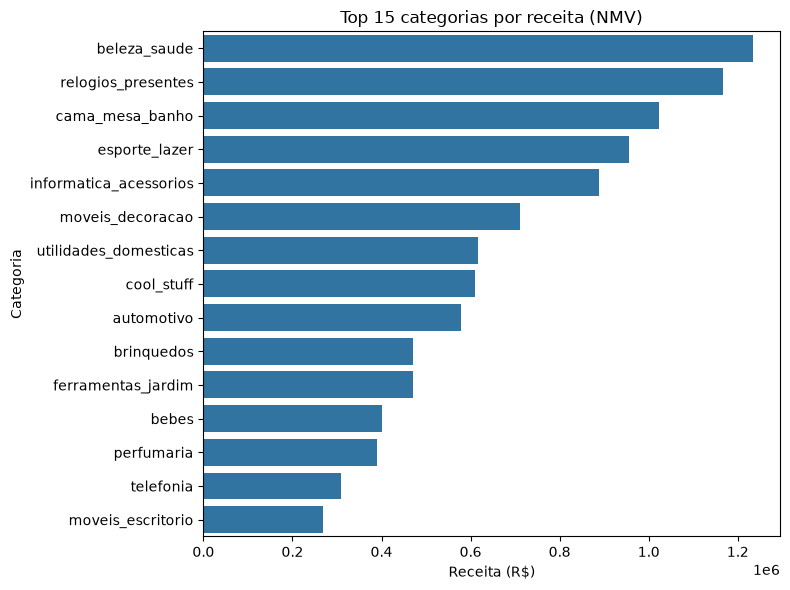

In [4]:
categorias = conn.sql("""
    WITH receita_categoria AS (
        SELECT
            p.product_category_name,
            boi.price
        FROM
            base_order_items boi
        INNER JOIN
            dim_products p ON boi.product_id = p.product_id
        WHERE TRUE
            AND boi.order_status = 'delivered'
    )
    SELECT
        product_category_name,
        SUM(price) AS receita_nmv,
        COUNT(*) AS n_itens,
        SUM(price)/COUNT(*) AS avg_price
    FROM
        receita_categoria
    GROUP BY
        product_category_name
    ORDER BY
        receita_nmv DESC
    LIMIT 15
""").df()

display(categorias)

plt.figure(figsize=(8, 6))
sns.barplot(data=categorias, y="product_category_name", x="receita_nmv")
plt.title("Top 15 categorias por receita (NMV)")
plt.xlabel("Receita (R$)")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

Análise das Categorias: A categoria de Beleza e Saúde apresenta a maior receita, mas não lidera em volume ou preço médio. Porém, vale destacar que o top3 é composto por: a maior receita (Beleza e Saúde), o maior preço médio (Relógios e Presentes) e a maior quantidade de vendas (Cama, Mesa e Banho). Isso indica que a receita das categorias é influenciada por diferentes combinações de volume de vendas e valor dos produtos.

## 2. Sazonalidade

,mes,receita_nmv,n_pedidos
0,2016-09-01,134.97,1
1,2016-10-01,40325.11,265
2,2016-12-01,10.90,1
3,2017-01-01,111798.36,750
4,2017-02-01,234223.40,1653
5,2017-03-01,359198.85,2546
6,2017-04-01,340669.68,2303
7,2017-05-01,489338.25,3546
8,2017-06-01,421923.37,3135
9,2017-07-01,481604.52,3872


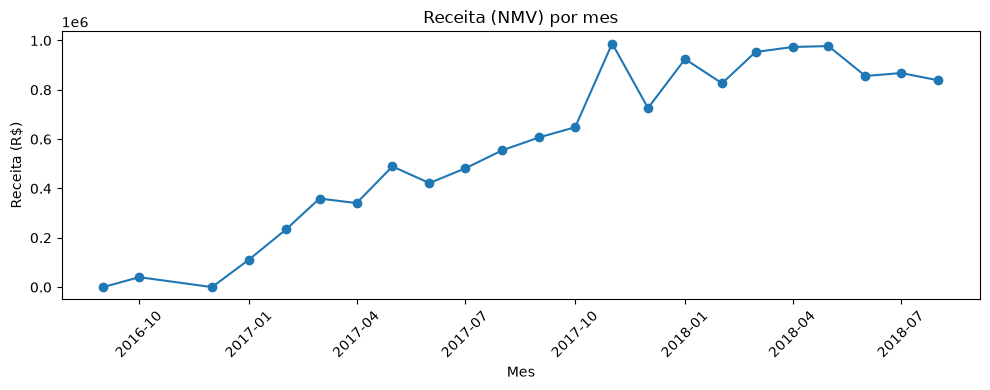

In [5]:
sazonalidade = conn.sql("""
    WITH pedidos_entregues AS (
        SELECT
            order_id,
            price,
            DATE_TRUNC('month', order_purchase_timestamp) AS mes
        FROM
            base_order_items
        WHERE TRUE
            AND order_status = 'delivered'
    )
    SELECT
        mes,
        SUM(price) AS receita_nmv,
        COUNT(DISTINCT order_id) AS n_pedidos
    FROM
        pedidos_entregues
    GROUP BY
        mes
    ORDER BY
        mes
""").df()

display(sazonalidade)

plt.figure(figsize=(10, 4))
plt.plot(sazonalidade["mes"], sazonalidade["receita_nmv"], marker="o")
plt.title("Receita (NMV) por mes")
plt.xlabel("Mes")
plt.ylabel("Receita (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Apesar do dataset conter apenas informações de um ano completo, e parte de outros dois, é possível ver um pico de vendas em novembro de 2017. Porém, como não há informações de outros meses de novembro, será necessário investigar para entender se pode se tratar de um pradrão sazonal.

### Hipótese 1: O pico de novembro de 2017 está relacionado à Black Friday.

,dia,receita_nmv,n_pedidos
0,2017-11-15,22591.40,176
1,2017-11-16,27674.54,219
2,2017-11-17,28711.29,185
3,2017-11-18,22713.91,141
4,2017-11-19,19932.66,157
5,2017-11-20,43405.98,219
6,2017-11-21,33600.85,222
7,2017-11-22,23951.51,190
8,2017-11-23,43102.33,268
9,2017-11-24,149916.58,1147


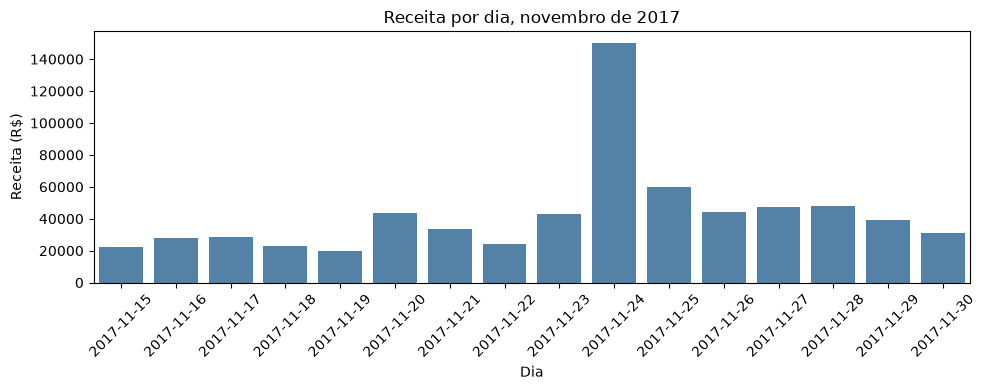

In [6]:
pico_novembro = conn.sql("""
    SELECT
        CAST(order_purchase_timestamp AS DATE) AS dia,
        SUM(price) AS receita_nmv,
        COUNT(DISTINCT order_id) AS n_pedidos
    FROM
        base_order_items
    WHERE TRUE
        AND order_status = 'delivered'
        AND order_purchase_timestamp >= '2017-11-15'
        AND order_purchase_timestamp < '2017-12-01'
    GROUP BY
        dia
    ORDER BY
        dia
""").df()

display(pico_novembro)

plt.figure(figsize=(10, 4))
sns.barplot(data=pico_novembro, x="dia", y="receita_nmv", color="steelblue")
plt.title("Receita por dia, novembro de 2017")
plt.xlabel("Dia")
plt.ylabel("Receita (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hipótese comprovada: O pico de vendas é na última sexta-feira de novembro, Black Friday.

### Análise Complementar: Os produtos vendidos na Black Friday são diferentes dos vendidos normalmente?

In [7]:
categorias_black_friday = conn.sql("""
    SELECT
        p.product_category_name,
        ROUND(SUM(boi.price), 2) AS receita,
        COUNT(*) AS n_itens
    FROM
        base_order_items boi
    INNER JOIN
        dim_products p ON boi.product_id = p.product_id
    WHERE TRUE
        AND boi.order_status = 'delivered'
        AND CAST(boi.order_purchase_timestamp AS DATE) = DATE '2017-11-24'
    GROUP BY
        p.product_category_name
    ORDER BY
        receita DESC
    LIMIT 10
""").df()

display(categorias_black_friday)

,product_category_name,receita,n_itens
0,relogios_presentes,17667.02,75
1,cama_mesa_banho,17585.24,192
2,beleza_saude,11719.62,88
3,moveis_decoracao,11534.22,134
4,informatica_acessorios,10859.22,70
5,esporte_lazer,8513.88,90
6,brinquedos,7836.84,71
7,perfumaria,7498.91,62
8,agro_industria_e_comercio,6331.60,7
9,ferramentas_jardim,6190.32,102


Análise Complementar: As categorias mais compradas nesse dia são as mesmas que já lideram a receita no geral (relogios_presentes, cama_mesa_banho, beleza_saude), só que em volume bem maior. Dessa forma, entende-se que a Black Friday amplifica as vendas, ao mesmo tempo que mantém as categorias mais rentáveis no topo.

Análise da Sazonalidade: Os dados indicam que há sazonalidade e que pode haver aumento das vendas em períodos comerciais. Além disso, os dados também mostram que a Black Friday não muda o padrão de compra, apenas intensificando a venda das categorias que já são majoritárias.

## 3. Impacto da entrega na recompra

In [8]:
conn.sql("""
    CREATE OR REPLACE TEMP VIEW pedidos_validos_cliente AS
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp,
        DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS atraso_dias
    FROM
        dim_orders o
    INNER JOIN
        dim_customers c ON o.customer_id = c.customer_id
    WHERE TRUE
        AND o.order_status = 'delivered'
        AND o.order_delivered_customer_date IS NOT NULL
        AND o.order_estimated_delivery_date IS NOT NULL
""")

conn.sql("""
    CREATE OR REPLACE TEMP VIEW pedido_inicial_cliente AS
    WITH numerado AS (
        SELECT
            customer_unique_id,
            order_id,
            order_purchase_timestamp,
            atraso_dias,
            ROW_NUMBER() OVER (
                PARTITION BY customer_unique_id
                ORDER BY order_purchase_timestamp, order_id
            ) AS numero_pedido
        FROM
            pedidos_validos_cliente
    )
    SELECT
        customer_unique_id,
        order_id,
        order_purchase_timestamp AS data_primeira_compra,
        DATE_TRUNC('month', order_purchase_timestamp) AS mes_coorte,
        CASE WHEN atraso_dias > 0 THEN 'atrasado' ELSE 'no prazo' END AS grupo_atraso
    FROM
        numerado
    WHERE TRUE
        AND numero_pedido = 1
""")

In [9]:
cohort = conn.sql("""
    WITH tamanho_grupo AS (
        SELECT
            grupo_atraso,
            COUNT(DISTINCT customer_unique_id) AS total_clientes
        FROM
            pedido_inicial_cliente
        GROUP BY
            grupo_atraso
    ),
    atividade AS (
        SELECT
            pi.customer_unique_id,
            pi.grupo_atraso,
            DATE_DIFF('month', pi.mes_coorte, DATE_TRUNC('month', pv.order_purchase_timestamp)) AS mes_relativo
        FROM
            pedido_inicial_cliente pi
        INNER JOIN
            pedidos_validos_cliente pv ON pv.customer_unique_id = pi.customer_unique_id
    )
    SELECT
        a.grupo_atraso,
        a.mes_relativo,
        COUNT(DISTINCT a.customer_unique_id) AS clientes_ativos,
        tg.total_clientes,
        ROUND(100.0 * COUNT(DISTINCT a.customer_unique_id) / tg.total_clientes, 2) AS pct_ativo
    FROM
        atividade a
    INNER JOIN
        tamanho_grupo tg ON a.grupo_atraso = tg.grupo_atraso
    WHERE TRUE
        AND a.mes_relativo BETWEEN 1 AND 6
    GROUP BY
        a.grupo_atraso,
        a.mes_relativo,
        tg.total_clientes
    ORDER BY
        a.grupo_atraso,
        a.mes_relativo
""").df()

display(cohort)

,grupo_atraso,mes_relativo,clientes_ativos,total_clientes,pct_ativo
0,atrasado,1,27,6355,0.42
1,atrasado,2,17,6355,0.27
2,atrasado,3,17,6355,0.27
3,atrasado,4,5,6355,0.08
4,atrasado,5,11,6355,0.17
5,atrasado,6,9,6355,0.14
6,no prazo,1,394,86995,0.45
7,no prazo,2,256,86995,0.29
8,no prazo,3,175,86995,0.20
9,no prazo,4,171,86995,0.20


,grupo_atraso,n_clientes,pct_recompra_90d
0,atrasado,6355,1.9
1,no prazo,86995,2.1


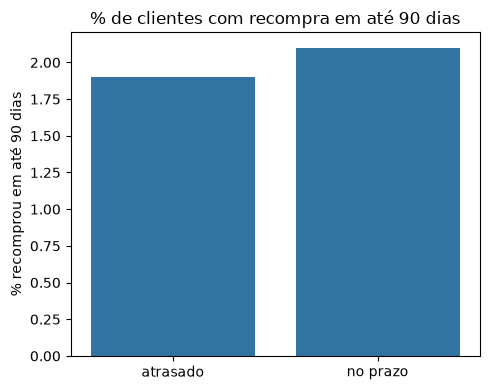

In [10]:
consolidado = conn.sql("""
    WITH proxima_compra AS (
        SELECT
            pv.customer_unique_id,
            pv.order_id,
            LEAD(pv.order_purchase_timestamp) OVER (
                PARTITION BY pv.customer_unique_id
                ORDER BY pv.order_purchase_timestamp, pv.order_id
            ) AS proxima_data
        FROM
            pedidos_validos_cliente pv
    )
    SELECT
        pi.grupo_atraso,
        COUNT(*) AS n_clientes,
        ROUND(100.0 * COUNT(*) FILTER (
            WHERE pc.proxima_data IS NOT NULL
            AND DATE_DIFF('day', pi.data_primeira_compra, pc.proxima_data) <= 90
        ) / COUNT(*), 1) AS pct_recompra_90d
    FROM
        pedido_inicial_cliente pi
    INNER JOIN
        proxima_compra pc
        ON pc.customer_unique_id = pi.customer_unique_id
        AND pc.order_id = pi.order_id
    GROUP BY
        pi.grupo_atraso
""").df()

display(consolidado)

plt.figure(figsize=(5, 4))
sns.barplot(data=consolidado, x="grupo_atraso", y="pct_recompra_90d")
plt.title("% de clientes com recompra em até 90 dias")
plt.xlabel("")
plt.ylabel("% recomprou em até 90 dias")
plt.tight_layout()
plt.show()

Análise Impacto da Entrega na Recompra: Dos clientes com mais de uma compra, 2,1% dos que receberam o primeiro pedido no prazo voltam a comprar, contra 1,9% dos que tiveram atraso, o que representa uma diferença de 10%. Porém, como a recompra é baixa em ambos os grupos, os dados indicam que o prazo de entrega pode não é decisivo para a recompra.

## 4. CLV por região

,customer_state,n_clientes,clv_mensal_medio,clv_mensal_mediano
0,PB,503,77.96,18.42
1,RR,40,67.88,13.42
2,RO,231,56.67,15.29
3,RN,464,54.33,15.41
4,AP,66,49.76,22.61
5,PI,464,49.32,15.81
6,PA,922,49.09,15.45
7,AC,76,48.87,14.77
8,SE,327,46.12,15.00
9,PE,1548,46.11,16.01


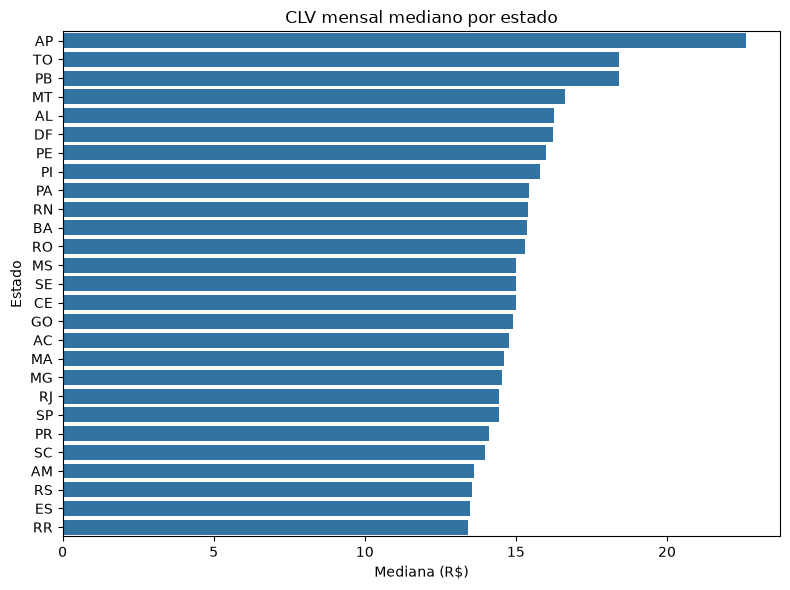

In [11]:
clv_regiao = conn.sql("""
    WITH pedidos_cliente AS (
        SELECT
            c.customer_unique_id,
            c.customer_state,
            boi.order_id,
            boi.order_purchase_timestamp,
            boi.price
        FROM
            base_order_items boi
        INNER JOIN
            dim_customers c ON boi.customer_id = c.customer_id
        WHERE TRUE
            AND boi.order_status = 'delivered'
    ),
    data_referencia AS (
        SELECT
            MAX(order_purchase_timestamp) AS data_maxima
        FROM
            pedidos_cliente
    ),
    pedidos_por_estado_cliente AS (
        SELECT
            customer_unique_id,
            customer_state,
            COUNT(DISTINCT order_id) AS n_pedidos_estado
        FROM
            pedidos_cliente
        GROUP BY
            customer_unique_id,
            customer_state
    ),
    estado_mais_frequente AS (
        SELECT
            customer_unique_id,
            customer_state,
            ROW_NUMBER() OVER (
                PARTITION BY customer_unique_id
                ORDER BY n_pedidos_estado DESC
            ) AS rn
        FROM
            pedidos_por_estado_cliente
    ),
    clv_cliente AS (
        SELECT
            pc.customer_unique_id,
            SUM(pc.price) AS clv_total,
            DATE_DIFF('month', MIN(pc.order_purchase_timestamp), dr.data_maxima) AS meses_tenure
        FROM
            pedidos_cliente pc
        CROSS JOIN
            data_referencia dr
        GROUP BY
            pc.customer_unique_id,
            dr.data_maxima
    )
    SELECT
        e.customer_state,
        COUNT(DISTINCT c.customer_unique_id) AS n_clientes,
        ROUND(AVG(c.clv_total / GREATEST(c.meses_tenure, 1)), 2) AS clv_mensal_medio,
        ROUND(MEDIAN(c.clv_total / GREATEST(c.meses_tenure, 1)), 2) AS clv_mensal_mediano
    FROM
        clv_cliente c
    INNER JOIN
        estado_mais_frequente e
        ON c.customer_unique_id = e.customer_unique_id
        AND e.rn = 1
    GROUP BY
        e.customer_state
    ORDER BY
        clv_mensal_medio DESC
""").df()

display(clv_regiao)

clv_ordenado_mediana = clv_regiao.sort_values("clv_mensal_mediano", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=clv_ordenado_mediana, y="customer_state", x="clv_mensal_mediano", order=clv_ordenado_mediana["customer_state"])
plt.title("CLV mensal mediano por estado")
plt.xlabel("Mediana (R$)")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()

Análise CLV: Para fins comparativos, foi calculado o CLV mensal mediano e considerado o estado onde o cliente realizou mais compras, caso tenha realizado compras em mais de um estado. A mediana foi utilizada porque a média apresenta maior variação entre os estados (R$ 36 a R$ 78), indicando influência de outliers, principalmente nos estados com menos clientes. AP apresenta o maior CLV mensal mediano (R$ 22,61), seguido por TO e PB. Já estados com maior número de clientes, como SP, RJ e MG, estão entre os menores CLVs. Porém, a mediana apresenta uma variação relativamente baixa entre os estados, de R$ 13 a R$ 23, indicando que o CLV típico dos clientes é semelhante entre as regiões.

## 5. Concentração de vendedores

,decil,n_vendedores,receita_decil,pct_receita_total
0,1,297,8873076.37,67.1
1,2,297,2006583.27,15.2
2,3,297,1026473.27,7.8
3,4,297,549968.17,4.2
4,5,297,328102.28,2.5
5,6,297,202659.24,1.5
6,7,297,117831.52,0.9
7,8,297,67111.11,0.5
8,9,297,36305.84,0.3
9,10,297,13387.04,0.1


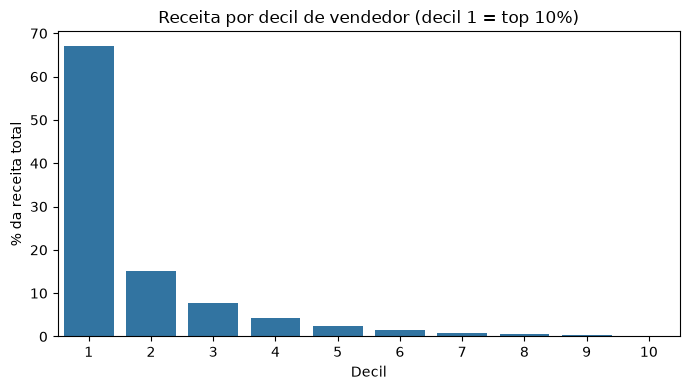

In [12]:
concentracao = conn.sql("""
    WITH receita_vendedor AS (
        SELECT
            seller_id,
            SUM(price) AS receita_nmv
        FROM
            base_order_items
        WHERE TRUE
            AND order_status = 'delivered'
        GROUP BY
            seller_id
    ),
    ranking AS (
        SELECT
            seller_id,
            receita_nmv,
            NTILE(10) OVER (ORDER BY receita_nmv DESC) AS decil
        FROM
            receita_vendedor
    )
    SELECT
        decil,
        COUNT(*) AS n_vendedores,
        ROUND(SUM(receita_nmv), 2) AS receita_decil,
        ROUND(100.0 * SUM(receita_nmv) / SUM(SUM(receita_nmv)) OVER (), 1) AS pct_receita_total
    FROM
        ranking
    GROUP BY
        decil
    ORDER BY
        decil
""").df()

display(concentracao)

plt.figure(figsize=(7, 4))
sns.barplot(data=concentracao, x="decil", y="pct_receita_total")
plt.title("Receita por decil de vendedor (decil 1 = top 10%)")
plt.xlabel("Decil")
plt.ylabel("% da receita total")
plt.tight_layout()
plt.show()

### Hipótese 1: a concentração vem de geografia

In [13]:
pct_mesmo_estado = conn.sql("""
    SELECT
        ROUND(100.0 * COUNT(*) FILTER (WHERE s.seller_state = c.customer_state) / COUNT(*), 1) AS pct_mesmo_estado
    FROM
        base_order_items boi
    INNER JOIN
        dim_sellers s ON boi.seller_id = s.seller_id
    INNER JOIN
        dim_customers c ON boi.customer_id = c.customer_id
    WHERE TRUE
        AND boi.order_status = 'delivered'
""").df()

display(pct_mesmo_estado)

,pct_mesmo_estado
0,36.2


Hipótese refutada: só 36,2% das vendas são entre vendedor e cliente do mesmo estado. O vendedor não depende de um mercado regional pra vender bem, então a localização dele não explica estar entre os maiores em receita.

### Hipótese 2: a concentração vem de baixa concorrência por categoria

In [14]:
top_vendedores = conn.sql("""
    WITH receita_vendedor AS (
        SELECT
            seller_id,
            SUM(price) AS receita_total
        FROM
            base_order_items
        WHERE TRUE
            AND order_status = 'delivered'
        GROUP BY
            seller_id
    ),
    receita_vendedor_categoria AS (
        SELECT
            boi.seller_id,
            p.product_category_name,
            SUM(boi.price) AS receita_categoria_vendedor
        FROM
            base_order_items boi
        INNER JOIN
            dim_products p ON boi.product_id = p.product_id
        WHERE TRUE
            AND boi.order_status = 'delivered'
        GROUP BY
            boi.seller_id,
            p.product_category_name
    ),
    categoria_principal AS (
        SELECT
            *,
            ROW_NUMBER() OVER (PARTITION BY seller_id ORDER BY receita_categoria_vendedor DESC) AS rn
        FROM
            receita_vendedor_categoria
    ),
    receita_categoria_total AS (
        SELECT
            product_category_name,
            SUM(receita_categoria_vendedor) AS receita_total_categoria,
            COUNT(DISTINCT seller_id) AS n_vendedores_categoria
        FROM
            receita_vendedor_categoria
        GROUP BY
            product_category_name
    )
    SELECT
        ROW_NUMBER() OVER (ORDER BY rv.receita_total DESC) AS ranking,
        ROUND(rv.receita_total, 0) AS receita_total,
        cp.product_category_name AS categoria_principal,
        rct.n_vendedores_categoria AS n_concorrentes_categoria,
        ROUND(100.0 * cp.receita_categoria_vendedor / rct.receita_total_categoria, 1) AS pct_participacao_categoria
    FROM
        receita_vendedor rv
    INNER JOIN
        categoria_principal cp
        ON rv.seller_id = cp.seller_id
        AND cp.rn = 1
    INNER JOIN
        receita_categoria_total rct ON cp.product_category_name = rct.product_category_name
    ORDER BY
        rv.receita_total DESC
    LIMIT 10
""").df()

display(top_vendedores)

,ranking,receita_total,categoria_principal,n_concorrentes_categoria,pct_participacao_categoria
0,1,226988.0,relogios_presentes,95,17.0
1,2,217940.0,pcs,9,74.7
2,3,196882.0,cama_mesa_banho,189,15.8
3,4,190917.0,relogios_presentes,95,16.2
4,5,186570.0,moveis_escritorio,30,64.0
5,6,165981.0,relogios_presentes,95,13.7
6,7,159817.0,cama_mesa_banho,189,14.8
7,8,139659.0,cool_stuff,259,21.9
8,9,138209.0,moveis_decoracao,352,15.6
9,10,131837.0,moveis_decoracao,352,5.4


Hipótese refutada na maioria dos casos: os 10 maiores vendedores competem com dezenas a centenas de outros vendedores na própria categoria, com participação individual baixa (5% a 22%).

Análise Vendedores: 10% dos vendedores concentram (decil 1) 67,1% da receita, mas as duas hipóteses que explicariam isso como um risco estrutural foram refutadas. Essa concentração não está relacionada à geografia, ou à falta de concorrência, na maioria dos casos. Dessa forma, apesar de poucos vendedores concentrarem grande parte das vendas, isso não se apresenta como um risco grande, já que, caso um desses vendedores deixe de trabalhar para a plataforma, outros da mesma categoria podem absorver as vendas.

# Alavancas adicionais

## 6. Itens por pedido e ticket médio

,grupo,grupo_ordem,n_pedidos,ticket_medio,valor_medio_item,pct_mesmo_produto_repetido
0,1 item,1,86843,129.70,129.70,NaN
1,2 itens,2,7392,173.85,86.93,66.5
2,3 itens,3,1306,237.46,79.15,80.7
3,4+ itens,4,937,387.03,77.69,92.4


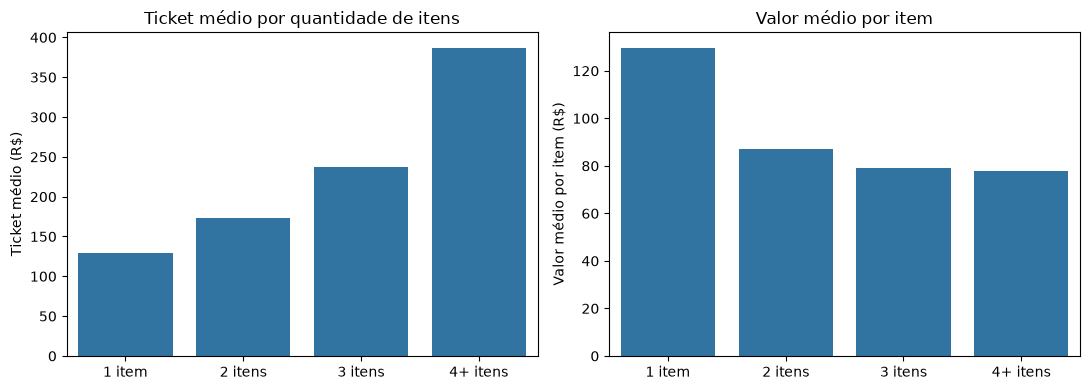

In [15]:
itens_pedido = conn.sql("""
    WITH pedidos AS (
        SELECT
            order_id,
            COUNT(*) AS n_itens,
            COUNT(DISTINCT product_id) AS n_produtos_distintos,
            SUM(price) AS valor_pedido
        FROM
            base_order_items
        WHERE TRUE
            AND order_status = 'delivered'
        GROUP BY
            order_id
    ),
    classificado AS (
        SELECT
            order_id,
            n_itens,
            valor_pedido,
            valor_pedido / n_itens AS valor_medio_item,
            CASE
                WHEN n_itens = 1 THEN '1 item'
                WHEN n_itens = 2 THEN '2 itens'
                WHEN n_itens = 3 THEN '3 itens'
                ELSE '4+ itens'
            END AS grupo,
            CASE
                WHEN n_itens = 1 THEN 1
                WHEN n_itens = 2 THEN 2
                WHEN n_itens = 3 THEN 3
                ELSE 4
            END AS grupo_ordem,
            CASE
                WHEN n_itens = 1 THEN NULL
                WHEN n_itens = n_produtos_distintos THEN 'produtos diferentes'
                ELSE 'mesmo produto repetido'
            END AS tipo_cesta
        FROM
            pedidos
    )
    SELECT
        grupo,
        grupo_ordem,
        COUNT(*) AS n_pedidos,
        ROUND(AVG(valor_pedido), 2) AS ticket_medio,
        ROUND(AVG(valor_medio_item), 2) AS valor_medio_item,
        ROUND(100.0 * COUNT(*) FILTER (WHERE tipo_cesta = 'mesmo produto repetido') / NULLIF(COUNT(*) FILTER (WHERE tipo_cesta IS NOT NULL), 0), 1) AS pct_mesmo_produto_repetido
    FROM
        classificado
    GROUP BY
        grupo,
        grupo_ordem
    ORDER BY
        grupo_ordem
""").df()

display(itens_pedido)

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=itens_pedido, x="grupo", y="ticket_medio", ax=eixos[0])
eixos[0].set_title("Ticket médio por quantidade de itens")
eixos[0].set_xlabel("")
eixos[0].set_ylabel("Ticket médio (R$)")

sns.barplot(data=itens_pedido, x="grupo", y="valor_medio_item", ax=eixos[1])
eixos[1].set_title("Valor médio por item")
eixos[1].set_xlabel("")
eixos[1].set_ylabel("Valor médio por item (R$)")

plt.tight_layout()
plt.show()

Análise Ticket Médio e Itens por pedido: A análise mostra que o ticket médio de quem compra mais itens é maior, o que é esperado, mas que o valor médio por item cai conforme a adição de itens. Além disso, um ponto importante é que, nos casos de pedido com mais de 1 item, o % de compra de produto repetido é muito alto, sendo 66% para quem compra 2 itens, 81% para 3 itens e 92% para 4 itens ou mais. Isso indica que, quem compra mais de um item, tem uma forte tendência a adquirir itens repetidos.

## 7. Mix de receita: cliente novo vs. recorrente

,grupo,n_clientes,receita_total,pct_receita
0,novo (1 pedido),90557,12493089.36,94.5
1,recorrente (2+),2801,728408.75,5.5


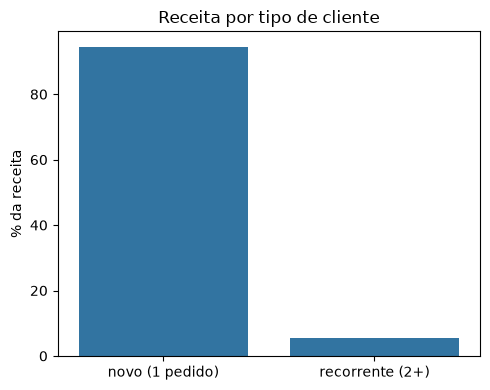

In [16]:
mix_cliente = conn.sql("""
    WITH receita_pedido_cliente AS (
        SELECT
            c.customer_unique_id,
            boi.order_id,
            SUM(boi.price) AS valor_pedido
        FROM
            base_order_items boi
        INNER JOIN
            dim_customers c ON boi.customer_id = c.customer_id
        WHERE TRUE
            AND boi.order_status = 'delivered'
        GROUP BY
            c.customer_unique_id,
            boi.order_id
    ),
    resumo_cliente AS (
        SELECT
            customer_unique_id,
            COUNT(DISTINCT order_id) AS n_pedidos,
            SUM(valor_pedido) AS receita_cliente
        FROM
            receita_pedido_cliente
        GROUP BY
            customer_unique_id
    )
    SELECT
        CASE WHEN n_pedidos = 1 THEN 'novo (1 pedido)' ELSE 'recorrente (2+)' END AS grupo,
        COUNT(*) AS n_clientes,
        ROUND(SUM(receita_cliente), 2) AS receita_total,
        ROUND(100.0 * SUM(receita_cliente) / SUM(SUM(receita_cliente)) OVER (), 1) AS pct_receita
    FROM
        resumo_cliente
    GROUP BY
        grupo
""").df()

display(mix_cliente)

plt.figure(figsize=(5, 4))
sns.barplot(data=mix_cliente, x="grupo", y="pct_receita")
plt.title("Receita por tipo de cliente")
plt.xlabel("")
plt.ylabel("% da receita")
plt.tight_layout()
plt.show()

Análise Mix de Receita: É possível identificar que a maioria esmagadora dos clientes (97,0%) é novo e fez apenas um pedido, sendo responsáveis pela maior parte da receita. Porém, o detalhe que mais chama atenção é a pequena quantidade de clientes que recompra. Esse gap pode ser uma oportunidade de fidelizar clientes, em vez de investir na aquisição de novos.

## 8. Review e recompra

### Hipótese 1: a nota do review reflete satisfação real

In [17]:
review_por_atraso = conn.sql("""
    WITH review_por_pedido AS (
        SELECT
            order_id,
            review_score,
            ROW_NUMBER() OVER (
                PARTITION BY order_id
                ORDER BY review_creation_date DESC
            ) AS rn
        FROM
            fct_reviews
    ),
    pedidos_com_grupo AS (
        SELECT
            order_id,
            CASE WHEN atraso_dias > 0 THEN 'atrasado' ELSE 'no prazo' END AS grupo_atraso
        FROM
            pedidos_validos_cliente
    )
    SELECT
        pg.grupo_atraso,
        COUNT(*) AS n_pedidos,
        ROUND(AVG(r.review_score), 2) AS review_score_medio
    FROM
        pedidos_com_grupo pg
    INNER JOIN
        review_por_pedido r
        ON pg.order_id = r.order_id
        AND r.rn = 1
    GROUP BY
        pg.grupo_atraso
""").df()

display(review_por_atraso)

,grupo_atraso,n_pedidos,review_score_medio
0,no prazo,89443,4.29
1,atrasado,6381,2.27


Hipótese confirmada: a nota cai de 4,29 pra 2,27 quando tem atraso.

### Hipótese 2: cliente mais satisfeito recompra mais

,grupo_satisfacao,n_clientes,pct_recompra_90d
0,insatisfeito (1-2),11914,2.06
1,neutro (3),7669,2.13
2,satisfeito (4-5),73152,2.03


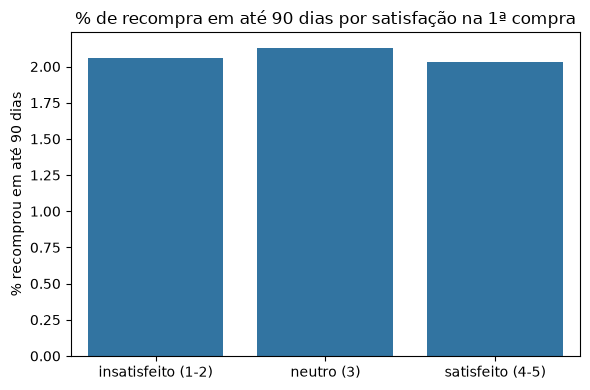

In [18]:
satisfacao_recompra = conn.sql("""
    WITH review_por_pedido AS (
        SELECT
            order_id,
            review_score,
            ROW_NUMBER() OVER (
                PARTITION BY order_id
                ORDER BY review_creation_date DESC
            ) AS rn
        FROM
            fct_reviews
    ),
    satisfacao_inicial AS (
        SELECT
            pi.customer_unique_id,
            pi.order_id,
            pi.data_primeira_compra,
            CASE
                WHEN r.review_score <= 2 THEN 'insatisfeito (1-2)'
                WHEN r.review_score = 3 THEN 'neutro (3)'
                ELSE 'satisfeito (4-5)'
            END AS grupo_satisfacao
        FROM
            pedido_inicial_cliente pi
        INNER JOIN
            review_por_pedido r
            ON pi.order_id = r.order_id
            AND r.rn = 1
    ),
    proxima_compra AS (
        SELECT
            customer_unique_id,
            order_id,
            LEAD(order_purchase_timestamp) OVER (
                PARTITION BY customer_unique_id
                ORDER BY order_purchase_timestamp, order_id
            ) AS proxima_data
        FROM
            pedidos_validos_cliente
    )
    SELECT
        si.grupo_satisfacao,
        COUNT(*) AS n_clientes,
        ROUND(100.0 * COUNT(*) FILTER (
            WHERE pc.proxima_data IS NOT NULL
            AND DATE_DIFF('day', si.data_primeira_compra, pc.proxima_data) <= 90
        ) / COUNT(*), 2) AS pct_recompra_90d
    FROM
        satisfacao_inicial si
    INNER JOIN
        proxima_compra pc
        ON pc.customer_unique_id = si.customer_unique_id
        AND pc.order_id = si.order_id
    GROUP BY
        si.grupo_satisfacao
    ORDER BY
        si.grupo_satisfacao
""").df()

display(satisfacao_recompra)

plt.figure(figsize=(6, 4))
sns.barplot(data=satisfacao_recompra, x="grupo_satisfacao", y="pct_recompra_90d")
plt.title("% de recompra em até 90 dias por satisfação na 1ª compra")
plt.xlabel("")
plt.ylabel("% recomprou em até 90 dias")
plt.tight_layout()
plt.show()

Hipótese refutada: a recompra em 90 dias fica em ~2% nos três grupos, satisfeito ou não.

Análise Review e Recompra: Os reviews e os atrasos em entrega não mudam a recompra, que fica em ~2% em todos os casos. A baixa incidência de clientes que fazem mais de um pedido não está atrelada a um fator específico.

## Resumo Final

Com base nas análises realizadas acima, três alavancas surgem como possibilidade de incremento de receita nos próximos 6 meses:

### Alavanca 1: Reativação de cliente

Os dados explorados no tópico de Mix de Receita (7) mostram que ~94% da receita provém de clientes que fizeram apenas uma compra. Além disso, as análises de entrega e review (3 e 8) mostram que a falta de recompra não está associada a atrasos ou experiência ruim, mas que se trata de um comportamento geral. Dessa forma, dentro do cenário de 6 meses, seria possível implementar mecânica de cashback para novas compras em até 90 dias. Além disso, dentro da mesma estratégia, também seria possível distribuir cupons de desconto para clientes que já compraram na plataforma há mais de 90 dias.

### Alavanca 2: Black Friday

A análise de sazonalidade (2) indica pico de vendas na Black Friday, com aumento de receita nas categorias mais rentáveis (1). Dessa forma, como o dataset termina em agosto/2018, indicando que essa seria a data "presente", uma outra estratégia possível dentro de 6 meses seria a preparação para a Black Friday. Essa iniciativa deveria incluir preparação de estoque e de vendedores, além de divulgação e possível distribuição de vantagens, como descontos ou promoções de leve 2 pague 1 (alavanca 3).

### Alavanca 3: Desconto por quantidade

A análise itens por pedido (6) revela que a maior parte dos clientes que compra mais de um item por pedido compram o mesmo produto em quantidade. Tendo em vista esse comportamento, uma possível alavanca de incremento de receita seria a de criar mecânicas de "leve 2 pague 1" e de divulgá-las por meio de campanhas de marketing, atalhos no carrinho de compras ou por estratégias de compra recorrente.